In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [40]:
#Cargar el dataset
df = pd.read_csv("netflix_titles.csv")

In [31]:
#Mostrar las primeras filas
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [32]:
# Mostrar las dimensiones
df.shape

(8807, 12)

In [33]:
#Mostrar los nombres de columnas
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [34]:
#ostrar tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [35]:
#Identificar la cantidad total de valores nulos por cada columna
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [36]:
#Calcular el porcentaje de valores faltantes
(df.isnull().sum() / len(df)) * 100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [37]:
#Detectar si existen filas exactamente iguales
df.duplicated().sum()

np.int64(0)

In [38]:
#Transformación - Estandarizar los nombres de las columnas a minúsculas y sin espacios
df.columns = df.columns.str.strip().str.lower()

In [45]:
#Se Borran las columna 'director', 'country' y 'cast' por la alta cantidad de nulos
df.drop(columns=["director"], inplace=True)
df.drop(columns=["country"], inplace=True)
df.drop(columns=["cast"], inplace=True)

In [43]:
#Se rellenan las columnas con pocos nulos usando la moda
df["date_added"] = df["date_added"].fillna(df["date_added"].mode()[0])
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])
df["duration"] = df["duration"].fillna(df["duration"].mode()[0])

In [46]:
#Comprobar si la cantidad total de valores nulos por cada columna es 0
df.isnull().sum()

show_id         0
type            0
title           0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

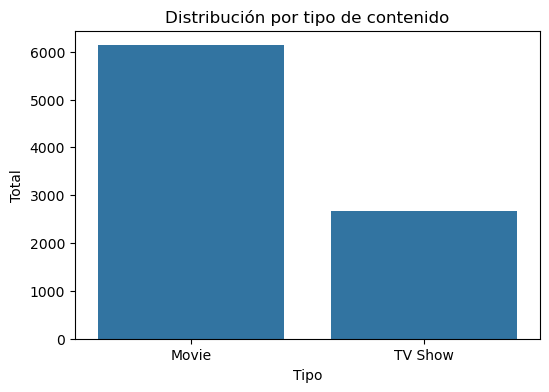

In [47]:
#Gráfica 1 - Distribución por tipo de contenido (Película o Serie)
plt.figure(figsize=(6,4))
sns.countplot(df, x="type")
plt.title("Distribución por tipo de contenido")
plt.xlabel("Tipo")
plt.ylabel("Total")
plt.show()

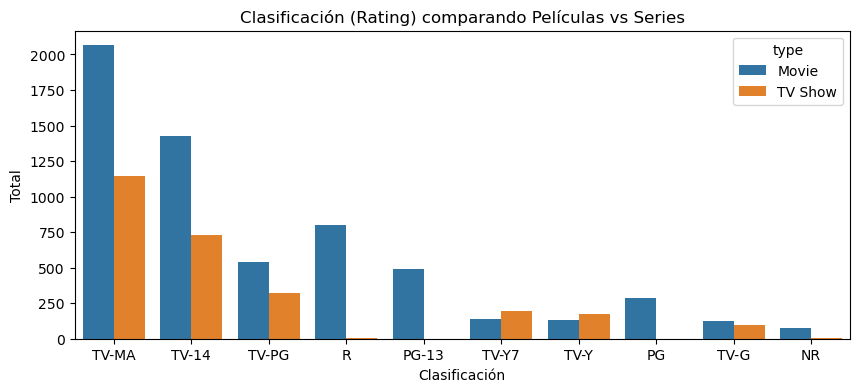

In [50]:
#Gráfica 2 - Top 10 Países con mayor cantidad de contenido
plt.figure(figsize=(10,4))
orden_rating = df["rating"].value_counts().index[:10]
sns.countplot(df, x="rating", hue="type", order=orden_rating)
plt.title("Clasificación (Rating) comparando Películas vs Series")
plt.xlabel("Clasificación")
plt.ylabel("Total")
plt.show()

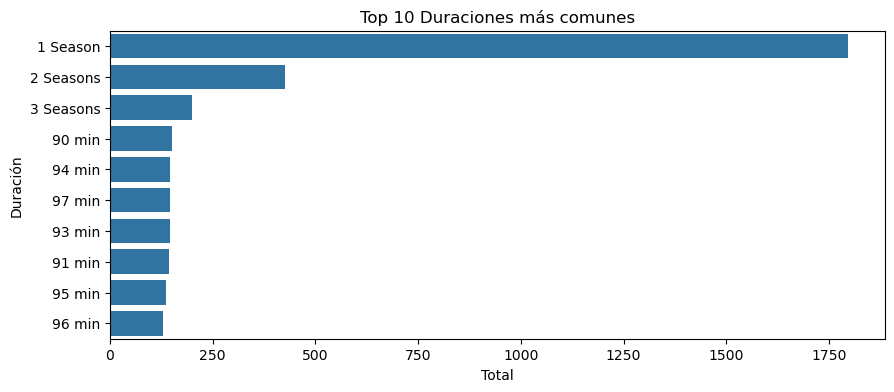

In [52]:
#Gráfica 3 - Top 10 Directores con más títulos
plt.figure(figsize=(10,4))
orden_duracion = df["duration"].value_counts().index[:10]
sns.countplot(df, y="duration", order=orden_duracion)
plt.title("Top 10 Duraciones más comunes")
plt.xlabel("Total")
plt.ylabel("Duración")
plt.show()

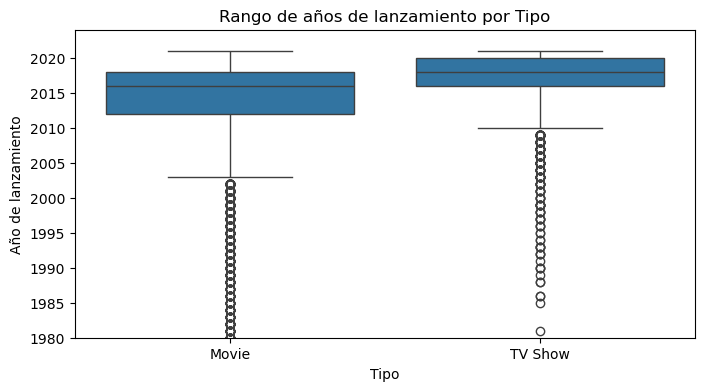

In [53]:
# Gráfica 4 - Boxplot (Diagrama de caja) de Años de lanzamiento por Tipo
plt.figure(figsize=(8,4))
sns.boxplot(df, x="type", y="release_year")
plt.title("Rango de años de lanzamiento por Tipo")
plt.xlabel("Tipo")
plt.ylabel("Año de lanzamiento")
plt.ylim(1980, 2024)
plt.show()

In [56]:
#4. Interpretación de patrones
#Preferencia por las películas: El catálogo está compuesto mayoritariamente por largometrajes, dejando a las series  en un claro segundo lugar en volumen.

#Crecimiento reciente: Existe un "boom" evidente de producciones lanzadas en la última década , lo que refleja la fuerte expansión del consumo por streaming.

#Enfoque en público adulto: Las clasificaciones dominantes son TV-MA  y TV-14 , lo que indica que la plataforma dirige su contenido principalmente a audiencias maduras en lugar de infantiles.